In [2]:
import os
import re

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.datasets import fetch_20newsgroups, load_files
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, log_loss, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'

##  Stochastic gradient descent
https://youtu.be/sDv4f4s2SB8

In [3]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [4]:
PATH_TO_WRITE_DATA = "../../../data/tmp/"
data_demo = pd.read_csv(os.path.join(DATA_PATH, "weights_heights.csv"))

Text(0, 0.5, 'Height in inches')

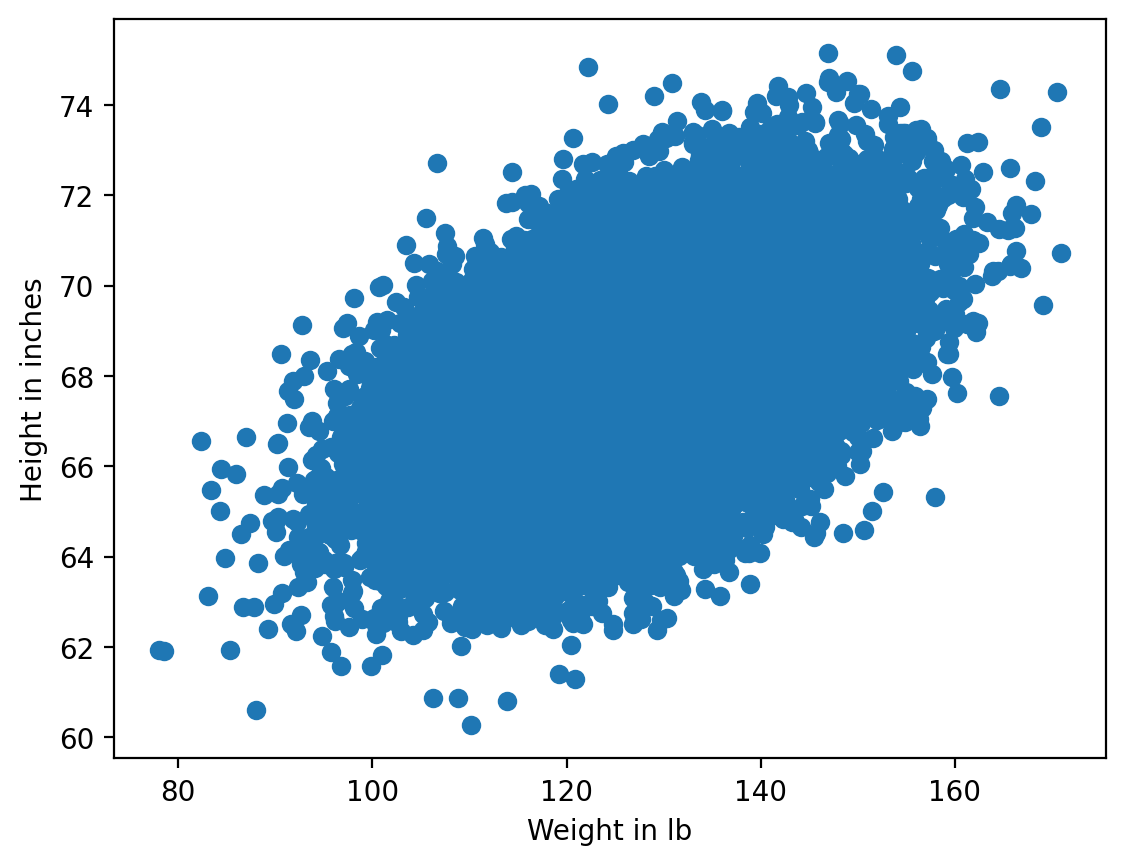

In [5]:
plt.scatter(data_demo["Weight"], data_demo["Height"])
plt.xlabel("Weight in lb")
plt.ylabel("Height in inches")

## Categorical feature processing

### Label Encoding

In [6]:
df = pd.read_csv("./bank/bank_train.csv")
labels = pd.read_csv("./bank/bank_train_target.csv", header=None)

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,student,single,high.school,no,no,no,telephone,jun,mon,901,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
1,46,admin.,married,university.degree,no,yes,no,cellular,aug,tue,208,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
2,49,blue-collar,married,basic.4y,unknown,yes,yes,telephone,jun,tue,131,5,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
3,31,technician,married,university.degree,no,no,no,cellular,jul,tue,404,1,999,0,nonexistent,-2.9,92.469,-33.6,1.044,5076.2
4,42,housemaid,married,university.degree,no,yes,no,telephone,nov,mon,85,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


We can see that most of the features are not represented by numbers. This poses a problem because we cannot use most machine learning methods (at least those implemented in scikit-learn) out-of-the-box.

<Axes: ylabel='education'>

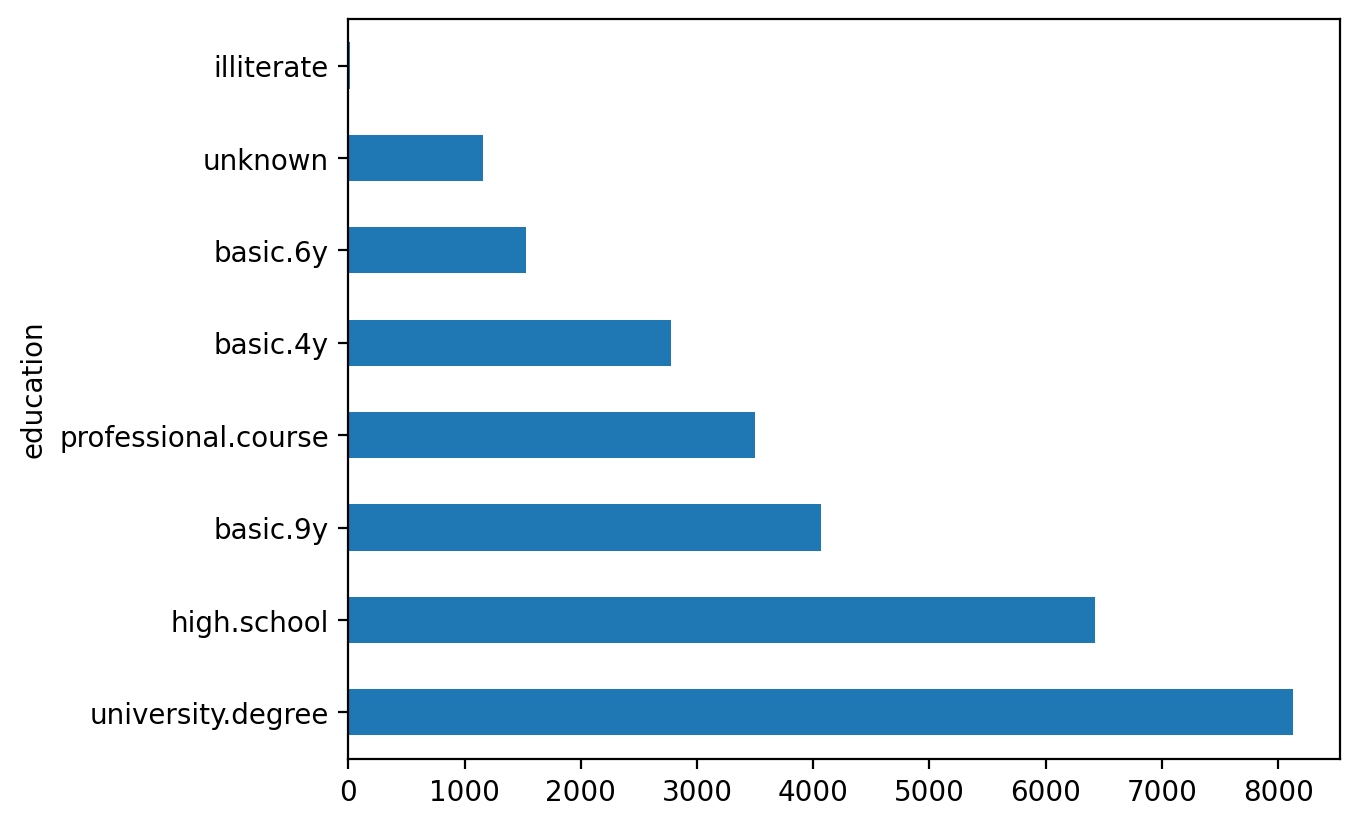

In [8]:
df["education"].value_counts().plot.barh()

The most straightforward solution is to map each value of this feature into a unique number. For example, we can map university.degree to 0, basic.9y to 1, and so on. You can use sklearn.preprocessing.LabelEncoder to perform this mapping.

In [9]:
label_encoder = LabelEncoder()

{0: 'basic.4y', 1: 'basic.6y', 2: 'basic.9y', 3: 'high.school', 4: 'illiterate', 5: 'professional.course', 6: 'university.degree', 7: 'unknown'}


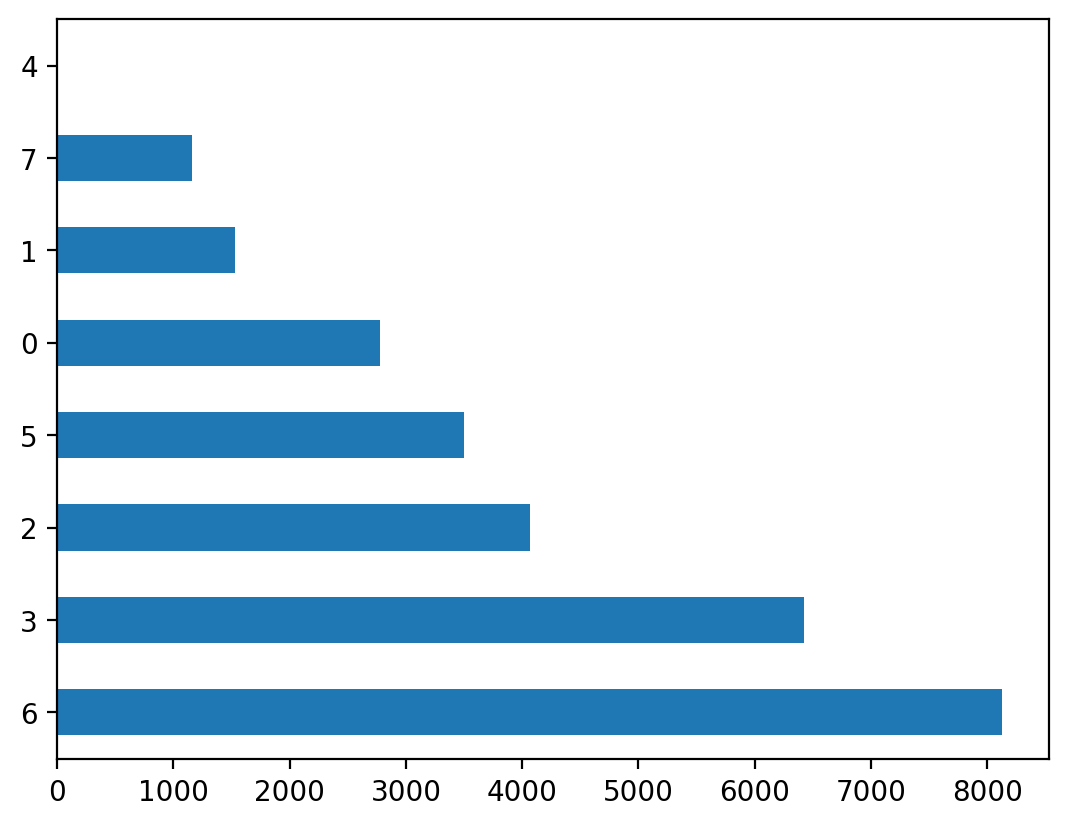

In [10]:
mapped_education = pd.Series(label_encoder.fit_transform(df["education"]))
mapped_education.value_counts().plot.barh()
print(dict(enumerate(label_encoder.classes_)))

In [11]:
df["education"] = mapped_education
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,student,single,3,no,no,no,telephone,jun,mon,901,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
1,46,admin.,married,6,no,yes,no,cellular,aug,tue,208,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
2,49,blue-collar,married,0,unknown,yes,yes,telephone,jun,tue,131,5,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
3,31,technician,married,6,no,no,no,cellular,jul,tue,404,1,999,0,nonexistent,-2.9,92.469,-33.6,1.044,5076.2
4,42,housemaid,married,6,no,yes,no,telephone,nov,mon,85,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


Let’s apply the transformation to other columns of type object.

In [12]:
categorical_columns = df.columns[df.dtypes == "object"].union(["education"])
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,8,2,3,0,0,0,1,4,1,901,1,999,0,1,1.4,94.465,-41.8,4.961,5228.1
1,46,0,1,6,0,2,0,0,1,3,208,2,999,0,1,1.4,93.444,-36.1,4.963,5228.1
2,49,1,1,0,1,2,2,1,4,3,131,5,999,0,1,1.4,94.465,-41.8,4.864,5228.1
3,31,9,1,6,0,0,0,0,3,3,404,1,999,0,1,-2.9,92.469,-33.6,1.044,5076.2
4,42,3,1,6,0,2,0,1,7,1,85,1,999,0,1,-0.1,93.200,-42.0,4.191,5195.8


The main issue with this approach is that we have now introduced some relative ordering where it might not exist.

In [13]:
def logistic_regression_accuracy_on(dataframe, labels):
    features = dataframe
    train_features, test_features, train_labels, test_labels = train_test_split(
        features, labels
    )

    logit = LogisticRegression()
    logit.fit(train_features, train_labels.values.ravel())
    return classification_report(test_labels, logit.predict(test_features))


print(logistic_regression_accuracy_on(df[categorical_columns], labels))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6125
           1       1.00      0.00      0.01       774

    accuracy                           0.89      6899
   macro avg       0.94      0.50      0.47      6899
weighted avg       0.90      0.89      0.84      6899



### One-Hot Encoding and  Hashing trick

Let's take a small DataFrame with **3 categorical features**:

| ID | Color | City     | Brand  |
| -- | ----- | -------- | ------ |
| 1  | Red   | New York | Nike   |
| 2  | Blue  | London   | Adidas |
| 3  | Green | Paris    | Puma   |
| 4  | Red   | London   | Nike   |

## Step 1: One-Hot Encoding

The unique values are:

* Color: Red, Blue, Green (3)
* City: New York, London, Paris (3)
* Brand: Nike, Adidas, Puma (3)

Total features = **3 + 3 + 3 = 9**

| Color_Red | Color_Blue | Color_Green | City_New York | City_London | City_Paris | Brand_Nike | Brand_Adidas | Brand_Puma |
| --------- | ---------- | ----------- | ------------- | ----------- | ---------- | ---------- | ------------ | ---------- |
| 1         | 0          | 0           | 1             | 0           | 0          | 1          | 0            | 0          |
| 0         | 1          | 0           | 0             | 1           | 0          | 0          | 1            | 0          |
| 0         | 0          | 1           | 0             | 0           | 1          | 0          | 0            | 1          |
| 1         | 0          | 0           | 0             | 1           | 0          | 1          | 0            | 0          |

There are **9 columns**.

---

# Step 2: Apply the Hashing Trick

Instead of creating 9 columns, suppose we decide to use **5 hash buckets**.

We hash the combination `"feature=value"`.

Let's pretend our hash function gives these bucket numbers:

| Feature Value | Bucket |
| ------------- | ------ |
| Color=Red     | 2      |
| Color=Blue    | 4      |
| Color=Green   | 1      |
| City=New York | 0      |
| City=London   | 2      |
| City=Paris    | 3      |
| Brand=Nike    | 1      |
| Brand=Adidas  | 4      |
| Brand=Puma    | 2      |

Notice something?

Several values map to **bucket 2**.

* Color=Red
* City=London
* Brand=Puma

These are **hash collisions**.

---

## Step 3: Build the hashed feature vectors

We have only **5 features** now:

```
Buckets
0 1 2 3 4
```

### Row 1

```
Color=Red      -> bucket 2
City=New York  -> bucket 0
Brand=Nike     -> bucket 1
```

Feature vector

| B0 | B1 | B2 | B3 | B4 |
| -- | -- | -- | -- | -- |
| 1  | 1  | 1  | 0  | 0  |

---

### Row 2

```
Color=Blue     -> bucket 4
City=London    -> bucket 2
Brand=Adidas   -> bucket 4
```

Feature vector

| B0 | B1 | B2 | B3 | B4 |
| -- | -- | -- | -- | -- |
| 0  | 0  | 1  | 0  | 2  |

Notice bucket 4 has **2**, because two different values landed there.

---

### Row 3

```
Color=Green -> bucket 1
City=Paris  -> bucket 3
Brand=Puma  -> bucket 2
```

Feature vector

| B0 | B1 | B2 | B3 | B4 |
| -- | -- | -- | -- | -- |
| 0  | 1  | 1  | 1  | 0  |

---

### Row 4

```
Color=Red    -> bucket 2
City=London  -> bucket 2
Brand=Nike   -> bucket 1
```

Feature vector

| B0 | B1 | B2 | B3 | B4 |
| -- | -- | -- | -- | -- |
| 0  | 1  | 2  | 0  | 0  |

Here, bucket 2 has a value of **2** because **Color=Red** and **City=London** both hash to the same bucket.

---

## Final hashed DataFrame

| ID | Bucket0 | Bucket1 | Bucket2 | Bucket3 | Bucket4 |
| -- | ------- | ------- | ------- | ------- | ------- |
| 1  | 1       | 1       | 1       | 0       | 0       |
| 2  | 0       | 0       | 1       | 0       | 2       |
| 3  | 0       | 1       | 1       | 1       | 0       |
| 4  | 0       | 1       | 2       | 0       | 0       |

Only **5 columns** instead of **9**.

---

## How this looks in scikit-learn

```python
import pandas as pd
from sklearn.feature_extraction import FeatureHasher

df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red'],
    'City': ['New York', 'London', 'Paris', 'London'],
    'Brand': ['Nike', 'Adidas', 'Puma', 'Nike']
})

# Convert each row to a list of feature=value strings
records = df.apply(
    lambda row: [f"{col}={row[col]}" for col in df.columns],
    axis=1
)

hasher = FeatureHasher(
    n_features=5,
    input_type='string'
)

X = hasher.transform(records)

hashed_df = pd.DataFrame(
    X.toarray(),
    columns=[f'Bucket{i}' for i in range(5)]
)

print(hashed_df)
```

The exact bucket assignments and values will differ from the hand-worked example because `FeatureHasher` uses a specific hash function and may assign positive or negative values (using signed hashing), but the core idea is the same: **many categorical values are compressed into a fixed number of hash buckets, reducing dimensionality at the cost of possible collisions.**


##  Vowpal Wabbit

### News. Binary classification.

In [14]:
newsgroups = fetch_20newsgroups(data_home="./")

In [15]:
newsgroups["target_names"]

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

Lets look at the first document in this collection:

In [16]:
text = newsgroups["data"][0]
target = newsgroups["target_names"][newsgroups["target"][0]]

print("-----")
print(target)
print("-----")
print(text.strip())
print("----")

-----
rec.autos
-----
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----
----


Now we convert the data into something Vowpal Wabbit can understand. We will throw away words shorter than 3 symbols. Here, we will skip some important NLP stages such as stemming and lemmatization; however, we will later see that VW solves the problem even without these steps.

In [17]:
def to_vw_format(document, label=None):
    return (
        str(label or "")
        + " |text "
        + " ".join(re.findall("\w{3,}", document.lower()))
        + "\n"
    )


to_vw_format(text, 1 if target == "rec.autos" else -1)

<>:5: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:5: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
C:\Users\rahul\AppData\Local\Temp\ipykernel_6788\1433298466.py:5: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  + " ".join(re.findall("\w{3,}", document.lower()))


'1 |text from lerxst wam umd edu where thing subject what car this nntp posting host rac3 wam umd edu organization university maryland college park lines was wondering anyone out there could enlighten this car saw the other day was door sports car looked from the late 60s early 70s was called bricklin the doors were really small addition the front bumper was separate from the rest the body this all know anyone can tellme model name engine specs years production where this car made history whatever info you have this funky looking car please mail thanks brought you your neighborhood lerxst\n'

Let's break it down line by line. This function converts a text document into the **Vowpal Wabbit (VW)** input format, which looks like:

```text
<label> |namespace feature1 feature2 feature3 ...
```

For example:

```text
1 |text car engine speed road
```

---

## The function

```python
def to_vw_format(document, label=None):
```

* `document` is a string containing the text.
* `label` is the class label (optional).

Example:

```python
document = "Cars are fast and fun to drive."
label = 1
```

---

### Line 1

```python
str(label or "")
```

If `label` exists, convert it to a string.

If `label` is `None`, use an empty string.

Examples:

```python
label = 1
str(label or "")
```

returns

```text
"1"
```

If

```python
label = None
```

then

```text
""
```

So this lets the function work for both training data (with labels) and unlabeled test data.

---

### Line 2

```python
+ " |text "
```

VW separates labels from features using `|`.

So now the string becomes

```text
1 |text
```

`text` is called a **namespace** in Vowpal Wabbit. It groups related features.

---

### Line 3

```python
document.lower()
```

Converts everything to lowercase.

```
"The CAR is Fast"
```

↓

```
"the car is fast"
```

This ensures `Car`, `CAR`, and `car` are treated as the same word.

---

### Line 4

```python
re.findall("\w{3,}", document.lower())
```

This is the most important line.

The regex

```python
\w{3,}
```

means:

* `\w` = letters, digits, or underscore
* `{3,}` = at least 3 characters long

So it extracts all words with **3 or more characters**.

Example:

```python
document = "The car is fast!"
```

After lowercase:

```text
"the car is fast!"
```

`findall()` returns

```python
['the', 'car', 'fast']
```

Notice

```
is
```

is removed because it has only 2 letters.

Another example:

```python
"I love AI and machine learning"
```

becomes

```python
['love', 'and', 'machine', 'learning']
```

"I" and "AI" are ignored because they're shorter than 3 characters.

---

### Line 5

```python
" ".join(...)
```

Suppose we have

```python
['the', 'car', 'fast']
```

Joining them gives

```text
"the car fast"
```

---

### Putting it together

Suppose

```python
document = "Cars are FAST and fun!"
label = 1
```

Step-by-step:

Lowercase

```text
cars are fast and fun!
```

Regex

```python
['cars', 'are', 'fast', 'and', 'fun']
```

Join

```text
cars are fast and fun
```

Final string

```text
1 |text cars are fast and fun
```

---

## The function call

```python
to_vw_format(text, 1 if target == "rec.autos" else -1)
```

This uses Python's **conditional expression**.

It's equivalent to:

```python
if target == "rec.autos":
    label = 1
else:
    label = -1

to_vw_format(text, label)
```

If the document belongs to the `"rec.autos"` category:

```python
label = 1
```

Otherwise:

```python
label = -1
```

This converts a **20-class classification problem** into a **binary classification** problem:

```
rec.autos      → +1
everything else → -1
```

---

## Example

Suppose

```python
text = "Honda makes great cars and engines."
target = "rec.autos"
```

The call

```python
to_vw_format(text, 1 if target == "rec.autos" else -1)
```

produces

```text
1 |text honda makes great cars and engines
```

If instead

```python
target = "sci.space"
```

the output becomes

```text
-1 |text honda makes great cars and engines
```

---

### Why do this?

Vowpal Wabbit expects input in a format like:

```text
<label> |namespace feature1 feature2 feature3 ...
```

So this function is simply **preprocessing raw text into the format that Vowpal Wabbit can train on** by:

* Lowercasing the text.
* Extracting words of length 3 or more.
* Joining them into a space-separated list of features.
* Prefixing the label (`1` or `-1`) and the namespace (`|text`).


We split the dataset into train and test and write these into separate files. We will consider a document as positive if it corresponds to rec.autos. Thus, we are constructing a model which distinguishes articles about cars from other topics:

In [18]:
all_documents = newsgroups["data"]
all_targets = [
    1 if newsgroups["target_names"][target] == "rec.autos" else -1 for target in newsgroups["target"]
]

In [19]:
train_documents, test_documents, train_labels, test_labels = train_test_split(
    all_documents, all_targets, random_state=7
)

with open(os.path.join("./", "20news_train.vw"), "w") as vw_train_data:
    for text, target in zip(train_documents, train_labels):
        vw_train_data.write(to_vw_format(text, target))
with open(os.path.join("./", "20news_test.vw"), "w") as vw_test_data:
    for text in test_documents:
        vw_test_data.write(to_vw_format(text))

Now, we pass the created training file to Vowpal Wabbit. We solve the classification problem with a hinge loss function (linear SVM). The trained model will be saved in the 20news_model.vw file:

In [20]:
# %pip install vowpalwabbit

In [21]:
from vowpalwabbit import pyvw
print("Imported successfully!")

Imported successfully!


In [3]:
!vw -d $PATH_TO_WRITE_DATA/20news_train.vw --loss_function hinge -f $PATH_TO_WRITE_DATA/20news_model.vw

'vw' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
 ##!vw -d $PATH_TO_WRITE_DATA/20news_train.vw --loss_function hinge -f $PATH_TO_WRITE_DATA/20news_model.vw
from vowpalwabbit import pyvw

vw = pyvw.Workspace("--loss_function hinge")

with open(f"./20news_train.vw") as f:
    for line in f:
        vw.learn(line)

vw.save(f"./20news_model.vw")
vw.finish()

In [27]:
# !vw -i $PATH_TO_WRITE_DATA/20news_model.vw -t -d $PATH_TO_WRITE_DATA/20news_test.vw -p $PATH_TO_WRITE_DATA/20news_test_predictions.txt
from vowpalwabbit import pyvw

# Load the trained model
vw = pyvw.Workspace(
    f"-i ./20news_model.vw -t"
)

predictions = []

with open(f"./20news_test.vw") as f:
    for line in f:
        pred = vw.predict(line)
        predictions.append(pred)

# Save predictions
with open(f"./20news_test_predictions.txt", "w") as f:
    for pred in predictions:
        f.write(f"{pred}\n")

vw.finish()

Now we load our predictions, compute AUC, and plot the ROC curve:

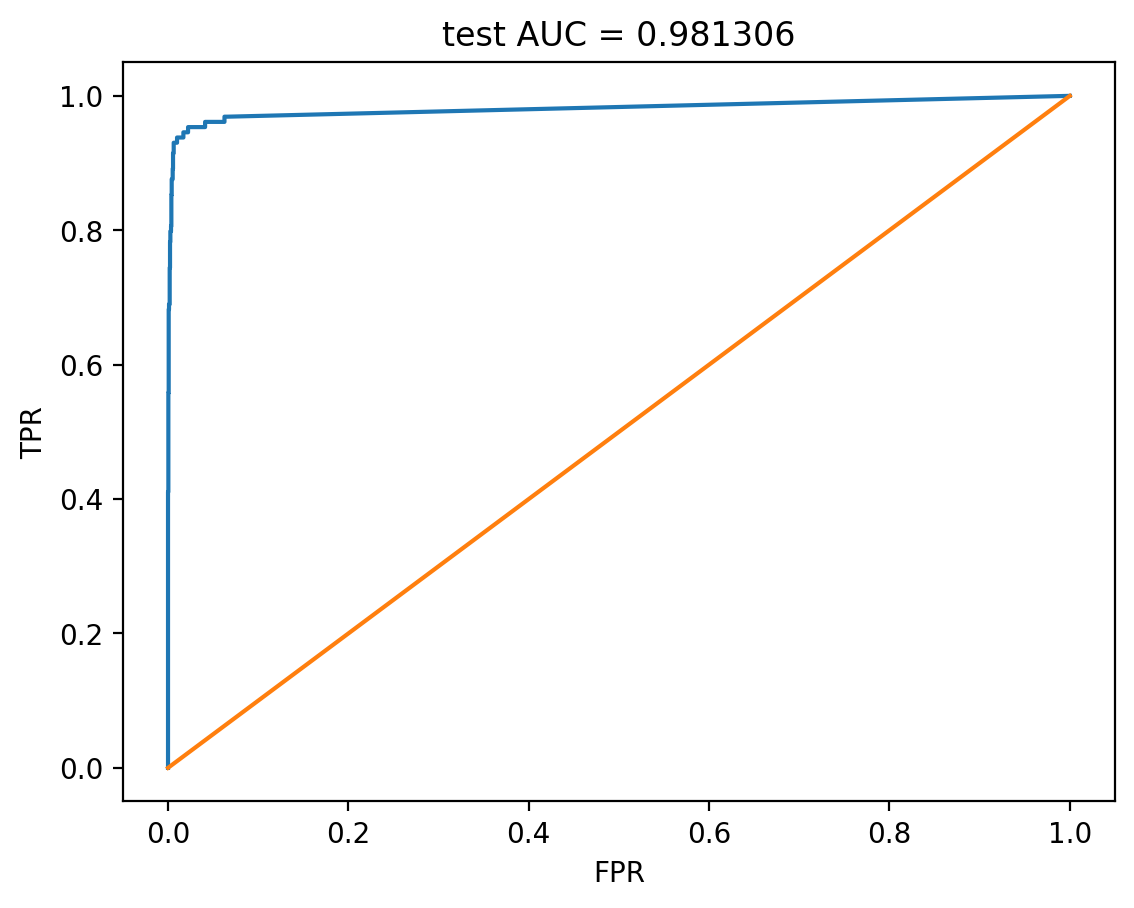

In [28]:
with open(os.path.join("./", "20news_test_predictions.txt")) as pred_file:
    test_prediction = [float(label) for label in pred_file.readlines()]

auc = roc_auc_score(test_labels, test_prediction)
roc_curve = roc_curve(test_labels, test_prediction)


plt.plot(roc_curve[0], roc_curve[1])
plt.plot([0, 1], [0, 1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("test AUC = %f" % (auc))
plt.axis([-0.05, 1.05, -0.05, 1.05]);

## News. Multiclass classification

We will use the same news dataset, but, this time, we will solve a multiclass classification problem. Vowpal Wabbit is a little picky – it wants labels starting from 1 till K, where K – is the number of classes in the classification task (20 in our case). So we will use LabelEncoder and add 1 afterwards (recall that LabelEncoder maps labels into range from 0 to K-1).